# IEMP Cuban Son and Salsa


The IEMP-CSS corpus is a collection of Cuban son and salsa recordings by the group Asere, a Havana based group of seven musicians. The original recordings were made in 2009 by Adrian Poole, and are publicly available as part of the Interpersonal Entrainment in Music Performance (IEMP) corpus (https://osf.io/37fws/). Five songs were recorded.


**Reference** Poole, A., Tarsitani, S., & Clayton, M. (2020, July 10). IEMP Cuban Son and Salsa. DOI: [10.17605/OSF.IO/SFXA2](https://doi.org/10.17605/OSF.IO/SFXA2)

**Dataset license:** [CC BY-NC-ND 4.0](https://osf.io/zj69b)
(I assume that extracting intervals counts as 'merely changing the format', and is not a derivative.)




In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rhythmic_segments import RhythmicSegments

import sys
sys.path.append('../')

from src.patdur import *
from src.utils import savefig, set_mpl_style, subplot_title
set_mpl_style()
from src.cluster import (
    clustered_pattern_duration_plot, 
    hdbscan_cluster, 
    show_cluster_transition_network
)

REFRESH = False

## Data format
The exact format of the dataset is described in detail [here](https://osf.io/sfxa2/files/ypuev).

For each song three annotations are provided: **metre annotations** "based on manually tapping the first beat of each cycle", **raw onset data** and **selected onset data**, "tabulated with metrical positions and other information". We use the raw onset data, which are split per instrument: "onset times for most instruments (vocals, crash cymbal and shakers were excluded) were extracted based on envelope characteristics using MIR Toolbox".

> Each CSS_[Recording]_Onsets_Raw.csv file contains the  raw onset data for all 
> instruments. In some cases these have been edited, so e.g. when the bongo is 
> played for half a track and the bell for the second half, only raw onsets from 
> the relevant time range are included in each column. Also, onset extraction of 
> the bell on song 5 uses different settings for different time ranges [...]
> Columns alternate between times and peak levels, e.g. Bass = time of bass 
> guitar onset, Bass peak = corresponding peak level

In [2]:
import os
from src.iemp_css import load_rhythmic_segments, load_metadata, load_metre_data, ALL_INSTRUMENTS

# I read location of data directory from .env file;
# you can just override this and specify whatever directory you like
DATA_DIR = Path(os.getenv("SHARED_DATA_DIR")) / "datasets/iemp-css"

metadata = load_metadata('../data/iemp-css-metadata.csv', data_dir=DATA_DIR)
rs = load_rhythmic_segments(data_dir=DATA_DIR)

skipping song 5, Bell


## Analyze meter

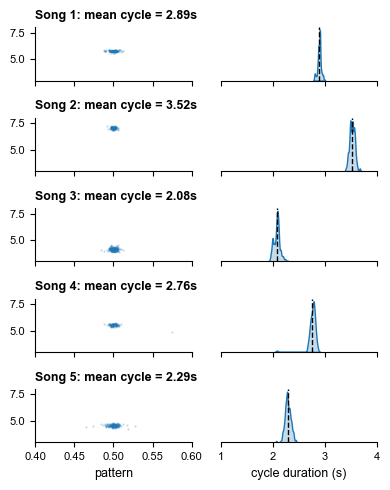

In [3]:
from src.iemp_css import load_metre_data

fig, axs = plt.subplots(5, 2, figsize=(4, 5), sharex='col')
for i, song_id in enumerate(metadata.index):
    metre = load_metre_data(song_id, data_dir=DATA_DIR)
    cycle_onsets = metre['Time']
    mean_cycle = np.mean(np.diff(cycle_onsets))

    # Pattern-duration plot
    plt.sca(axs[i, 0])
    title = f'{song_id.replace("_", " ")}: mean cycle = {mean_cycle:.2f}s'
    plt.title(title, x=0, ha='left', fontweight='bold')
    cycle_rs = RhythmicSegments.from_events(cycle_onsets, length=2)
    plt.scatter(cycle_rs.patterns[:, 0], cycle_rs.durations, marker='.', s=2, alpha=.2)
    plt.xlim(.4, .6)
    plt.ylim(3, 8)
    sns.despine(ax=plt.gca())

    # Density plot
    plt.sca(axs[i, 1])
    sns.kdeplot(np.diff(cycle_onsets), fill=True, bw_adjust=0.5)
    sns.despine(left=True, ax=plt.gca())
    plt.yticks([])
    plt.ylabel('')
    plt.xlim(1, 4)
    plt.axvline(mean_cycle, color='k', linestyle='--', linewidth=1)

axs[-1, 0].set_xlabel('pattern')
axs[-1, 1].set_xlabel('cycle duration (s)')

plt.tight_layout() 
savefig('iemp-css/metrical-cycles', refresh=REFRESH)


## Clustered plots

In [4]:
# song_num = 3
# instrument = 'bell'
# song_rs = rs.query(f'song_num == {song_num}')
# instrument_rs = song_rs.query(f'instrument == "{instrument}"')

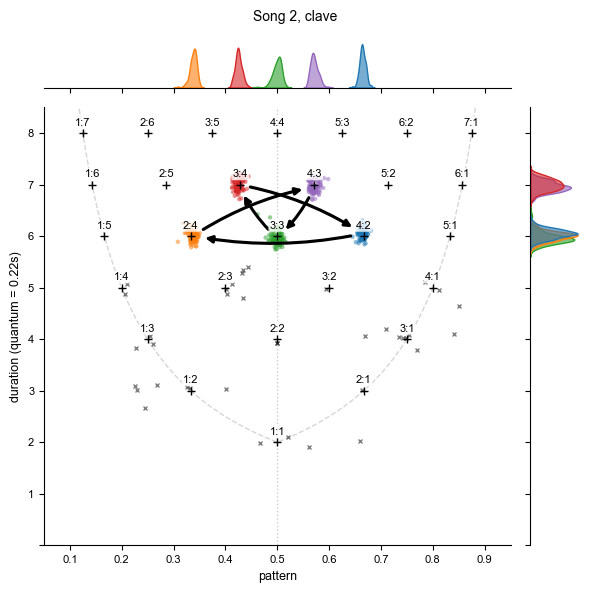

In [5]:
def show_instrument(rs, song_num, instrument, ax = None):
    if ax is not None:
        plt.sca(ax)
    song_rs = rs.query(f'song_num == {song_num}')
    instrument_rs = song_rs.query(f'instrument == "{instrument}"')

    # Clustered pattern duration plot
    g = clustered_pattern_duration_plot(
        instrument_rs, 
        min_cluster_size=10,
        min_transitions=15
    )

    # Quantal
    pulse = metadata.loc[f'Song_{song_num}', 'pulse_mean']
    quantal_pattern_duration_plot(pulse, ax=g.ax_joint)
    g.ax_joint.set_ylim(0*pulse, pulse*8.5)
    g.ax_joint.set_xlim(0.05, .95)
    
    plt.suptitle(f'Song {song_num}, {instrument}', fontsize=10)
    plt.tight_layout()

show_instrument(rs, 2, 'clave')

In [6]:
for song_num in range(1, 6):
    song_rs = rs.query(f'song_num == {song_num}').filter_by_duration(max_quantile=.97)
    instruments = song_rs.meta['instrument'].unique()

    for instrument in instruments:
        try:
            show_instrument(rs, song_num, instrument)
        except:
            print('Something went wrong', song_num, instrument)
        
        dir = f'iemp-css/song_{song_num}'
        if not os.path.exists(dir):
            os.makedirs(dir)
        savefig(f'{dir}/song_{song_num}-{instrument}', refresh=REFRESH)
        plt.close()

## One plot per song

In [7]:
from src.utils import subplots_grid

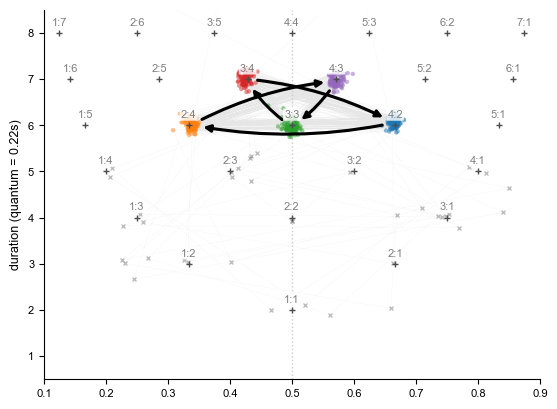

In [ ]:
def instrument_subplot(
        rs, song_num, instrument, 
        max_dur=None, 
        ylim=(0.5, 8.5), xlim=(0.1, .9), 
        ax = None, 
        annotate_pulse=False, annotate_bpm=False,
        hdbscan_kws={}, 
    ):
    if ax is None:
        ax = plt.gca()
    pulse = metadata.loc[f'Song_{song_num}', 'pulse_mean']
    song_rs = rs.query(f'song_num == {song_num}')
    instrument_rs = song_rs.query(f'instrument == "{instrument}"')
    if max_dur:
        instrument_rs = instrument_rs.filter_by_duration(max_value=max_dur * pulse)


    if 'min_cluster_size' not in hdbscan_kws:
        hdbscan_kws['min_cluster_size'] = 10
    labeled_rs, labeled, unlabeled = hdbscan_cluster(instrument_rs,  **hdbscan_kws)
    hue_order = labeled.meta["label"].value_counts().index
    sns.scatterplot(
        x=labeled.patterns[:, 0], y=labeled.durations, 
        hue=labeled.meta['label'], hue_order=hue_order, 
        s=10, lw=0, alpha=.5,
        ax=ax)
    
    # Trajectory in the background
    ax.plot(labeled_rs.patterns[:, 0], labeled_rs.durations, c='.9', lw=0.1, zorder=-1)

    # Mark unlabeled points in black
    ax.plot(unlabeled.patterns[:, 0], unlabeled.durations, "x", c='.5', alpha=.5, ms=3, markeredgewidth=1)

    # Transition network
    min_transitions = 1.5 * hdbscan_kws['min_cluster_size']
    show_cluster_transition_network(labeled_rs, "label", min_transitions=min_transitions, ax=ax)

    # Quantal
    pulse = metadata.loc[f'Song_{song_num}', 'pulse_mean']
    quantal_pattern_duration_plot(
        pulse, 
        ax=ax, quantum_boundary=False,
        annotate_ratios_kws=dict(marker_kws=dict(color='.3', ms=5), label_kws=dict(c='.5'))
    )
    ax.axvline(0.5, c="0.8", lw=1, zorder=-1, ls=":")
    ax.set_ylim(ylim[0] * pulse, pulse * ylim[1])
    ax.set_xlim(xlim)
    ax.legend_.remove()
    sns.despine(ax=ax)

    if annotate_pulse:
        ax.annotate(f'16th-note {pulse:.2f}s', xy=(.05,.05), xycoords='axes fraction', fontsize=8)
    if annotate_bpm:
        ax.annotate(f'{(60 * 1/pulse/4):.0f}bpm', xy=(.95,.05), xycoords='axes fraction', fontsize=8, ha='right')
    # ax.set_title(f'Song {song_num}, {instrument}', fontsize=10)
    # plt.tight_layout()

instrument_subplot(rs, 2, 'clave')

## Four instruments

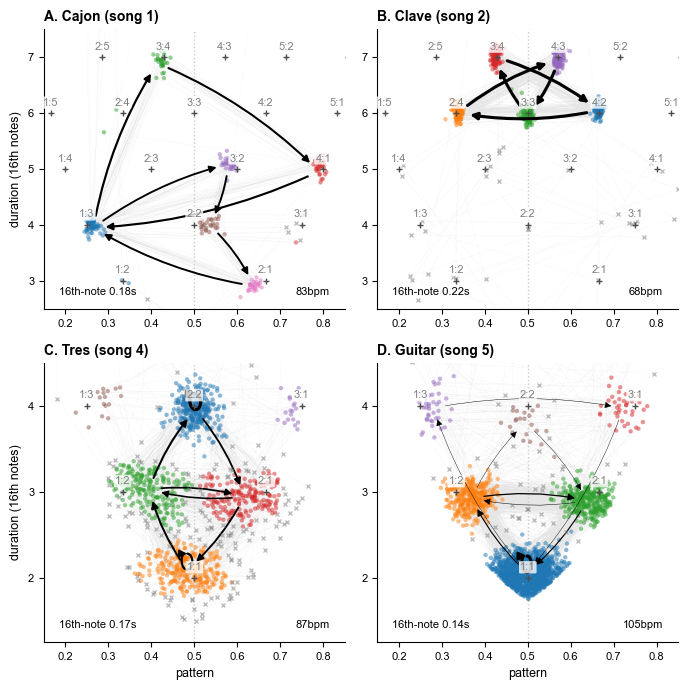

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(7,7))

kws = dict(annotate_bpm=True, annotate_pulse=True, xlim=(0.15, 0.85))
instrument_subplot(rs, 1, 'cajon', ax=axs[0, 0], ylim=(2.5, 7.5), **kws)
subplot_title(0, 'Cajon (song 1)', ax=axs[0, 0])

instrument_subplot(rs, 2, 'clave', ax=axs[0, 1], ylim=(2.5, 7.5), **kws)
subplot_title(1, 'Clave (song 2)', ax=axs[0, 1])

instrument_subplot(rs, 4, 'tres', ax=axs[1, 0],  ylim=(1.25, 4.5), **kws)
subplot_title(2, 'Tres (song 4)', ax=axs[1, 0])

instrument_subplot(rs, 5, 'guitar', ax=axs[1, 1], ylim=(1.25, 4.5), **kws)
subplot_title(3, 'Guitar (song 5)', ax=axs[1, 1])

for ax in axs.ravel():
    ax.set_ylabel('')
axs[1,0].set_ylabel('duration (16th notes)')
axs[0,0].set_ylabel('duration (16th notes)')
axs[1,0].set_xlabel('pattern')
axs[1,1].set_xlabel('pattern')

plt.tight_layout()
savefig('iemp-css/iemp-css-selection', refresh=REFRESH)

### Song 1

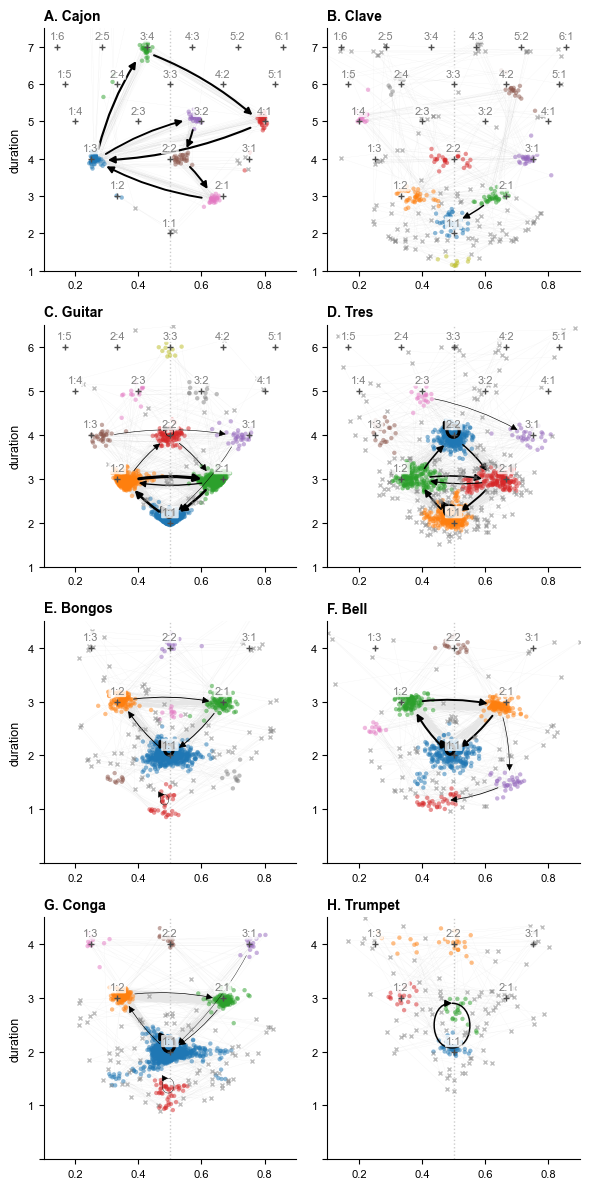

In [ ]:
song_num = 1
instruments = rs.query(f'song_num=={song_num}').meta['instrument'].unique()
fig, axs = subplots_grid(len(instruments), ratios=(3, 3), max_ncols=2, sharey='row')

  
instrument_subplot(rs, 1, 'cajon', ax=axs[0, 0])
instrument_subplot(rs, 1, 'clave', ax=axs[0, 1], ylim=(1, 7.5), max_dur=7.5)
instrument_subplot(rs, 1, 'guitar', ax=axs[1, 0], ylim=(1, 6.5), max_dur=6.5)
instrument_subplot(rs, 1, 'tres', ax=axs[1, 1], ylim=(1, 6.5), max_dur=6.5)
instrument_subplot(rs, 1, 'bongos', ax=axs[2,0], ylim=(0, 5.5), max_dur=5.5)
instrument_subplot(rs, 1, 'bell', ax=axs[2,1], ylim=(0, 4.5), max_dur=4.5)
instrument_subplot(rs, 1, 'conga', ax=axs[3,0], ylim=(0, 4.5), max_dur=4.5)
instrument_subplot(rs, 1, 'trumpet', ax=axs[3,1], ylim=(0, 4.5), max_dur=4.5)

instruments = ['cajon', 'clave', 'guitar', 'tres', 'bongos', 'bell', 'conga', 'trumpet']
for i, instr in enumerate(instruments):
    subplot_title(i, instr.capitalize(), ax=axs.ravel()[i])

for i in range(4):
    axs[i,0].set_ylabel('duration')

plt.tight_layout()
savefig('iemp-css/song-1-instruments', refresh=REFRESH)